In [6]:
import numpy as np
import matplotlib.pyplot as plt


rng = np.random.default_rng(42)


N = 200
X = np.vstack([
    rng.normal([-2, -2], 1.0, (N, 2)),
    rng.normal([2,  2], 0.5, (N, 2))
])
y = np.array([0]*N + [1]*N, dtype=float)


def sigmoid(z): return 1 / (1 + np.exp(-z))

def bce(theta, X, y):
    p = sigmoid(X @ theta)
    return -np.mean(y * np.log(p + 1e-15) + (1-y) * np.log(1-p + 1e-15))

def grad(theta, X, y):
    return X.T @ (sigmoid(X @ theta) - y) / len(y)

def sgd_train(X, y, batch_size, lr=0.1, epochs=100):
    Xb = np.column_stack([np.ones(len(X)), X])
    theta = np.zeros(Xb.shape[1])
    losses, accs = [], []
    idx = np.arange(len(X))
    for _ in range(epochs):
        rng.shuffle(idx)
        for i in range(0, len(X), batch_size):
            b = idx[i:i+batch_size]
            theta -= lr * grad(theta, Xb[b], y[b])
        losses.append(bce(theta, Xb, y))
        accs.append(np.mean((sigmoid(Xb @ theta) >= 0.5) == y))
    return losses, accs, theta


# Exercise 1

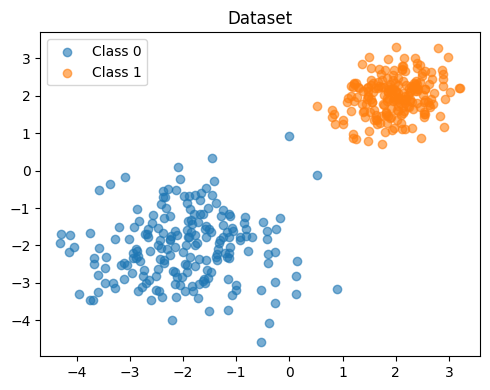

In [7]:
# dataset plot
plt.figure(figsize=(5, 4))
plt.scatter(*X[y==0].T, label='Class 0', alpha=0.6)
plt.scatter(*X[y==1].T, label='Class 1', alpha=0.6)
plt.legend(); plt.title('Dataset'); plt.tight_layout(); plt.show()


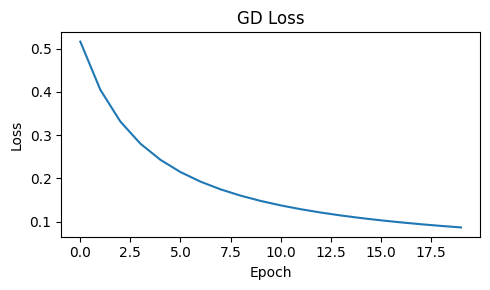

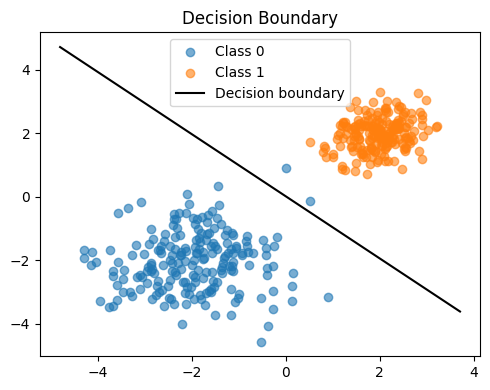

In [8]:
losses_gd, _, theta = sgd_train(X, y, batch_size=len(X), lr=0.1, epochs=20)
Xb = np.column_stack([np.ones(len(X)), X])

plt.figure(figsize=(5, 3))
plt.plot(losses_gd)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GD Loss')
plt.tight_layout()
plt.show()

x1 = np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 200)
x2 = -(theta[0] + theta[1]*x1) / theta[2]
plt.figure(figsize=(5, 4))
plt.scatter(*X[y==0].T, label='Class 0', alpha=0.6)
plt.scatter(*X[y==1].T, label='Class 1', alpha=0.6)
plt.plot(x1, x2, 'k-', label='Decision boundary')
plt.legend()
plt.title('Decision Boundary')
plt.tight_layout()
plt.show()


Since $\Theta^T x$ is a linear function of $x$, this set is a hyperplane and in 2 dimensions a line.

# Exercise 2

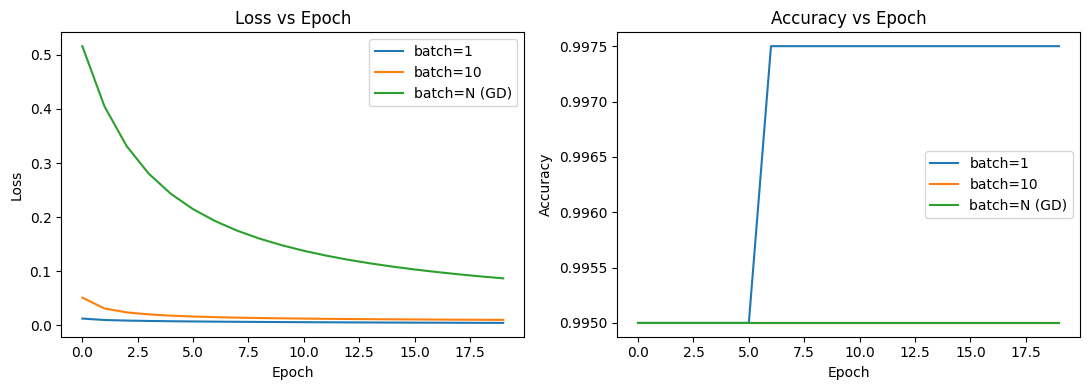

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for bs in [1, 10, len(X)]:
    ls, ac, _ = sgd_train(X, y, bs, epochs=20)
    lbl = f'batch={bs if bs < len(X) else "N (GD)"}'
    ax1.plot(ls, label=lbl)
    ax2.plot(ac, label=lbl)
ax1.set(xlabel='Epoch', ylabel='Loss',     title='Loss vs Epoch')
ax2.set(xlabel='Epoch', ylabel='Accuracy', title='Accuracy vs Epoch')
ax1.legend()
ax2.legend()
plt.tight_layout()
plt.show()


The variance of the stochastic gradient estimator is $\text{Var}[\hat{g}] \propto \sigma^2_{\text{sample}} / N_{\text{batch}}$, so smaller batches produce noisier gradient estimates. At $N_{\text{batch}} = 1$ each update uses a single sample that may be highly unrepresentative of the full loss landscape, causing the loss and accuracy curves to oscillate heavily. At $N_{\text{batch}} = N$ (full GD) the gradient is exact and the loss decreases monotonically. Batch size 10 sits in between: the curves are smoother than single-sample SGD but still show some noise.

In terms of convergence speed, small batches update parameters $N / N_{\text{batch}}$ times per epoch, so they make many more gradient steps and tend to make faster initial progress.

# Exercise 3

In [10]:
def evaluate(theta, Xb, y, threshold=0.5):
    p    = sigmoid(Xb @ theta)
    yhat = (p >= threshold).astype(int)
    TP = np.sum((yhat==1) & (y==1)); FP = np.sum((yhat==1) & (y==0))
    FN = np.sum((yhat==0) & (y==1)); TN = np.sum((yhat==0) & (y==0))
    acc  = (TP+TN) / len(y)
    prec = TP/(TP+FP) if TP+FP else 0
    rec  = TP/(TP+FN) if TP+FN else 0
    f1   = 2*prec*rec/(prec+rec) if prec+rec else 0
    print(
        f"threshold={threshold:.1f} | TP={TP} FP={FP} FN={FN} TN={TN} "
        f"| acc={acc:.3f}  prec={prec:.3f}  rec={rec:.3f}  F1={f1:.3f}"
    )

for t in [0.3, 0.5, 0.7]:
    evaluate(theta, Xb, y, t)


threshold=0.3 | TP=200 FP=3 FN=0 TN=197 | acc=0.993  prec=0.985  rec=1.000  F1=0.993
threshold=0.5 | TP=200 FP=2 FN=0 TN=198 | acc=0.995  prec=0.990  rec=1.000  F1=0.995
threshold=0.7 | TP=200 FP=0 FN=0 TN=200 | acc=1.000  prec=1.000  rec=1.000  F1=1.000


Lowering the threshold will mean that more points will be classified positively which will then rais the false positive rate. This means that the denominator of $precision\coloneqq TP / (TP+FP)$ will grow making precision go down. Dually, lowering the threshold means classifying less points negatively and reduce the false postive rate in the denominator of the formula of recall.
Increasing the the threshold will have the opposite effect on false positive and false negative rates and so will have the opposite effect on the precision and recall metrics.

On this dataset the two Gaussians are well separated and the model is highly confident, so all three thresholds achieve near-perfect metrics. Specifically, recall is unchanged at 1 for any threshold tested, while precision decreases minimally when lowering the threshold.

The right balance between precision and recall depends on the cost of each error type. In medical screening a false negative  (missing a sick patient) is far more dangerous than a false positive (which results in no more than a scare), so a low threshold and high recall is preferred to penalize false negatives. In email spam filtering, a false positive can be more disruptive than letting through occasional spam, so a higher threshold and high precision is preferred. F1 averages both, but in practice the asymmetric costs of the application should drive the choice.

# Exercise 4

In [11]:
data = np.loadtxt('assets/diabetes.csv', delimiter=',', skiprows=1)
X4, y4 = data[:, :-1], data[:, -1]
X4s = (X4 - X4.mean(0)) / X4.std(0)

def adam_train(X, y, batch_size, lr=1e-3, epochs=100, b1=0.9, b2=0.999, eps=1e-8):
    Xb = np.column_stack([np.ones(len(X)), X])
    theta = np.zeros(Xb.shape[1])
    m, v = np.zeros_like(theta), np.zeros_like(theta)
    losses, accs, idx, t = [], [], np.arange(len(X)), 0
    for _ in range(epochs):
        rng.shuffle(idx)
        for i in range(0, len(X), batch_size):
            g = grad(theta, Xb[idx[i:i+batch_size]], y[idx[i:i+batch_size]])
            t += 1
            m = b1*m + (1-b1)*g
            v = b2*v + (1-b2)*g**2
            theta -= lr * (m/(1-b1**t)) / (np.sqrt(v/(1-b2**t)) + eps)
        losses.append(bce(theta, Xb, y))
        accs.append(np.mean((sigmoid(Xb @ theta) >= 0.5) == y))
    return losses, accs, theta

losses_sgd4, accs_sgd4, theta_sgd4   = sgd_train(X4s, y4, batch_size=32, lr=1e-3, epochs=200)
losses_adam4, accs_adam4, theta_adam4 = adam_train(X4s, y4, batch_size=32, lr=1e-3, epochs=200)
Xb4 = np.column_stack([np.ones(len(X4s)), X4s])


Standardizing features to zero mean and unit variance is essential for three related reasons.

*Conditioning.* If features have very different scales (e.g. glucose in $[0, 200]$ vs BMI in $[0, 67]$), the Hessian of the loss is ill-conditioned: curvature is high along the large-scale directions and low along the small-scale ones, exactly the situation studied in Exercise 3 of the gradient-descent homework. Gradient descent must use a step small enough to avoid diverging in the steep directions, making negligible progress in the flat ones.

*Stable optimization.* With standardized features the loss landscape is more isotropic. All weights have comparable gradient magnitudes, so a single shared learning rate works reasonably well for every parameter simultaneously. Without normalization one might need to tune a separate learning rate per feature — impractical and fragile.

*Meaningful gradient magnitudes.* The gradient of the BCE loss w.r.t. $\theta_j$ is $\frac{1}{N}\sum_i (\hat{y}_i - y_i) x_{ij}$. A feature with a large numeric range produces large gradient components regardless of its predictive value, effectively drowning out features with small ranges. Standardizing puts every feature on equal footing so the magnitude of a gradient component reflects the feature's actual contribution to the loss.

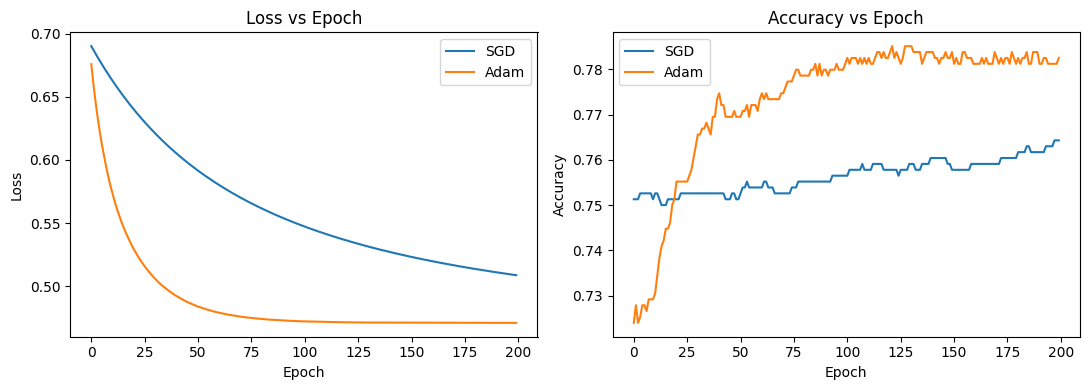

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for ls, ac, lbl in [(losses_sgd4, accs_sgd4, 'SGD'), (losses_adam4, accs_adam4, 'Adam')]:
    ax1.plot(ls, label=lbl); ax2.plot(ac, label=lbl)
ax1.set(xlabel='Epoch', ylabel='Loss', title='Loss vs Epoch')
ax2.set(xlabel='Epoch', ylabel='Accuracy', title='Accuracy vs Epoch')
ax1.legend(); ax2.legend(); plt.tight_layout(); plt.show()


--- SGD ---
threshold=0.5 | TP=159 FP=72 FN=109 TN=428 | acc=0.764  prec=0.688  rec=0.593  F1=0.637
--- Adam ---
threshold=0.5 | TP=157 FP=56 FN=111 TN=444 | acc=0.783  prec=0.737  rec=0.586  F1=0.653


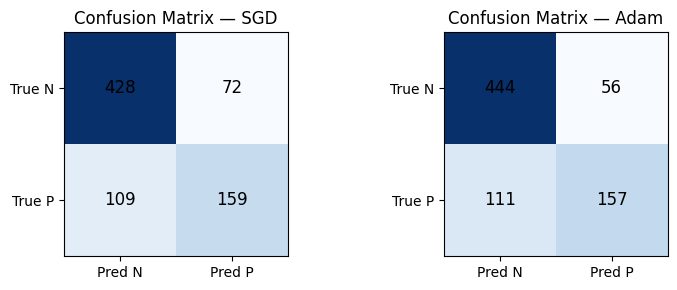

In [13]:
for name, theta in [('SGD', theta_sgd4), ('Adam', theta_adam4)]:
    print(f'--- {name} ---'); evaluate(theta, Xb4, y4)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for ax, theta, title in zip(axes, [theta_sgd4, theta_adam4], ['SGD', 'Adam']):
    yhat = (sigmoid(Xb4 @ theta) >= 0.5).astype(int)
    cm = np.array([[np.sum((yhat==0)&(y4==0)), np.sum((yhat==1)&(y4==0))],
                   [np.sum((yhat==0)&(y4==1)), np.sum((yhat==1)&(y4==1))]])
    ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=12)
    ax.set(xticks=[0,1], yticks=[0,1],
           xticklabels=['Pred N','Pred P'], yticklabels=['True N','True P'],
           title=f'Confusion Matrix — {title}')
plt.tight_layout(); plt.show()


Adam converges faster in the first few epochs: its loss curve drops steeply and its accuracy climbs quickly, then plateaus. SGD's loss curve decreases more gradually; accuracy follows a similarly slower, noisier trajectory.

Both methods reach comparable final accuracy by epoch 200, but Adam gets there in fewer epochs. This advantage comes from Adam's per-parameter adaptive step sizes, which effectively precondition the gradient and handle the heterogeneous feature scales even after standardization.

Adam converges faster than SGD because it maintains running estimates of the first moment $\hat{m}_k$ (momentum) and the second moment $\hat{v}_k$ (uncentered variance) of the gradient. The effective per-parameter step automatically scales the update: parameters with consistently large gradients get smaller effective steps (preventing overshooting) while parameters with small or infrequent gradients get larger effective steps (preventing stagnation). This is analogous to diagonal preconditioningit adapts the learning rate to the local curvature of each parameter dimension, addressing exactly the ill-conditioning issue that plagues vanilla SGD.

The confusion matrices confirm that both settle at roughly the same operating point (similar TP/FP/FN/TN), meaning Adam's benefit here is purely in convergence speed, not in final solution quality.